To perform basic NLP tasks on textual data.

In [ ]:
import numpy as np
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense # Changed SimpleRNN to LSTM
from tensorflow.keras.preprocessing import sequence
from tensorflow.keras.callbacks import EarlyStopping # Added EarlyStopping

In [ ]:
# 1. Load the IMDB dataset (top 10,000 most frequent words)
max_features = 10000
maxlen = 100 # Limit reviews to 100 words for faster training
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=max_features)

/usr/local/lib/python3.12/dist-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


In [ ]:
# 2. Preprocess: Pad sequences to ensure uniform input length
# Shorter reviews are padded with zeros; longer ones are truncated
x_train = sequence.pad_sequences(x_train, maxlen=maxlen)
x_test = sequence.pad_sequences(x_test, maxlen=maxlen)


In [ ]:
# 3. Build the RNN Model (now LSTM)
model = Sequential([
    # Embedding layer: 10k vocab size, 64-dimensional dense vectors (increased from 32)
    Embedding(max_features, 64, input_length=maxlen),
    # LSTM layer with 64 hidden units (changed from SimpleRNN, increased units)
    LSTM(64),
    # Output layer: Sigmoid for binary classification (0 or 1)
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
# 4. Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

In [ ]:
# 5. Train the model with Early Stopping

# Define Early Stopping callback
early_stopping = EarlyStopping(
    monitor='val_loss',  # Monitor validation loss
    patience=3,          # Number of epochs with no improvement after which training will be stopped
    restore_best_weights=True # Restore model weights from the epoch with the best value of the monitored quantity
)

history = model.fit(x_train, y_train,
          epochs=10,         # Increased epochs as EarlyStopping will handle overfitting
          batch_size=64,
          validation_split=0.2,
          callbacks=[early_stopping]) # Added early stopping callback

Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - accuracy: 0.7808 - loss: 0.4545 - val_accuracy: 0.8294 - val_loss: 0.3793
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - accuracy: 0.8914 - loss: 0.2742 - val_accuracy: 0.8418 - val_loss: 0.3568
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9233 - loss: 0.2024 - val_accuracy: 0.8442 - val_loss: 0.3870
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9439 - loss: 0.1529 - val_accuracy: 0.8296 - val_loss: 0.4249
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.9585 - loss: 0.1161 - val_accuracy: 0.8328 - val_loss: 0.5051


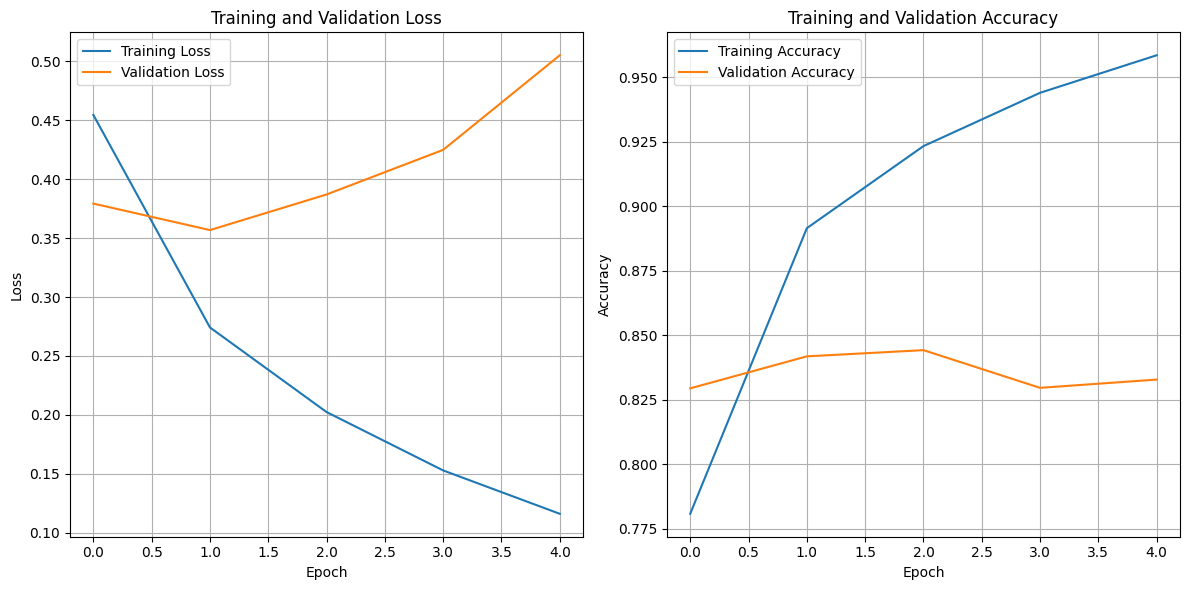

In [ ]:
import matplotlib.pyplot as plt

# Get training history
hist = history.history

# Plot training and validation loss
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(hist['loss'], label='Training Loss')
plt.plot(hist['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Plot training and validation accuracy
plt.subplot(1, 2, 2)
plt.plot(hist['accuracy'], label='Training Accuracy')
plt.plot(hist['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [ ]:
# 6. Evaluate on test data
loss, accuracy = model.evaluate(x_test, y_test)
print(f"Test Accuracy: {accuracy:.2f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8422 - loss: 0.3597
Test Accuracy: 0.84
